In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from spatial_manifolds.detect_grids import (
    cell_classification_of1,
    compute_of_tcs,
    plot_vr_rate_map_trials_ax,
)

base = "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_0_classification/"
cell_classifications = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

# ── Build mouse_days from top-N sessions by GC count ──────────────────────
top_n = 3

_gc_counts = (
    cell_classifications[cell_classifications['cell_type'] == 'GC']
    .groupby(['mouse', 'day'])
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index(name='n_gc')
)
_gc_counts['mouse'] = _gc_counts['mouse'].astype(int)
_gc_counts['day']   = _gc_counts['day'].astype(int)

mouse_days = (
    _gc_counts.groupby('mouse')['day']
    .apply(list)
    .to_dict()
)
print(f"Top {top_n} sessions by GC count:")
print(_gc_counts[['mouse', 'day', 'n_gc']].to_string(index=False))
print(f"\nmouse_days = {mouse_days}")

def _empty_scheme():
    return dict(gcs_rows=[], ngs_rows=[], gc_maps=[], ngs_maps=[])

s1 = _empty_scheme()
s2 = _empty_scheme()
sc = _empty_scheme()

def _fill_maps(cells_df, tcs, out_list):
    """Append rate maps sorted by grid score descending."""
    if 'grid_score' in cells_df.columns:
        cells_df = cells_df.sort_values('grid_score', ascending=False)
    for _, row in cells_df.iterrows():
        cid = int(row['cluster_id'])
        if cid in tcs:
            out_list.append(tcs[cid])

def _fill_maps_best_score(cells_df, tcs_of1, tcs_of2, ref_df1, ref_df2, out_list):
    """One map per cell: pick from whichever session has the higher grid score.
    Cells are ordered by their best grid score across both sessions (descending)."""
    gs1 = ref_df1.set_index('cluster_id')['grid_score'] if len(ref_df1) > 0 else pd.Series(dtype=float)
    gs2 = ref_df2.set_index('cluster_id')['grid_score'] if len(ref_df2) > 0 else pd.Series(dtype=float)
    cells_df = cells_df.copy()
    cells_df['_best_gs'] = cells_df['cluster_id'].apply(
        lambda cid: max(gs1.get(cid, -np.inf), gs2.get(cid, -np.inf))
    )
    cells_df = cells_df.sort_values('_best_gs', ascending=False)
    for _, row in cells_df.iterrows():
        cid = int(row['cluster_id'])
        score1 = gs1.get(cid, -np.inf)
        score2 = gs2.get(cid, -np.inf)
        if score1 >= score2 and cid in tcs_of1:
            out_list.append(tcs_of1[cid])
        elif cid in tcs_of2:
            out_list.append(tcs_of2[cid])
        elif cid in tcs_of1:
            out_list.append(tcs_of1[cid])

def plot_gc_and_ngs_of_rate_maps(
    gc_maps,
    ngs_maps,
    title="Grid cells (top) / NGS cells (bottom)",
    max_per_row=10,
    save_path=None,
):
    n_gc = len(gc_maps)
    n_ngs = len(ngs_maps)

    if n_gc == 0 or n_ngs == 0:
        print(f"Need at least one GC and one NGS cell. GC={n_gc}, NGS={n_ngs}")
        return

    rows_gc  = max(int(np.ceil(n_gc  / max_per_row)), 1)
    rows_ngs = max(int(np.ceil(n_ngs / max_per_row)), 1)
    ncols = max(int(np.ceil(n_gc / rows_gc)), int(np.ceil(n_ngs / rows_ngs)))

    spacer_rows = 1
    nrows_total = rows_gc + spacer_rows + rows_ngs

    fig, axes = plt.subplots(nrows_total, ncols,
                             figsize=(ncols * 0.5, nrows_total * 0.5), squeeze=False)
    fig.subplots_adjust(wspace=0.1, hspace=0.1)

    def _plot_block(maps, row_start):
        for idx, rm in enumerate(maps):
            r = row_start + idx // ncols
            c = idx % ncols
            if r >= nrows_total:
                break
            axes[r, c].imshow(rm, cmap="viridis", origin="lower")
            axes[r, c].axis("off")

    _plot_block(gc_maps,  row_start=0)
    _plot_block(ngs_maps, row_start=rows_gc + spacer_rows)

    for r in range(nrows_total):
        for c in range(ncols):
            if len(axes[r, c].images) == 0:
                axes[r, c].axis("off")

    fig.suptitle(f"{title}\nGC n={n_gc}  |  NGS n={n_ngs}", fontsize=9)
    fig.tight_layout(rect=[0, 0, 0.3, 0.3])

    if save_path:
        plt.savefig(save_path, dpi=500)
    plt.show()

Top 3 sessions by GC count:
 mouse  day  n_gc
    21   21    49
    26   19    47
    25   25    44

mouse_days = {21: [21], 25: [25], 26: [19]}


Processing M25 D25...
OF1  - GC: 33, NGS: 56
OF2  - GC: 28, NGS: 52
Comb - GC: 44, NGS: 49


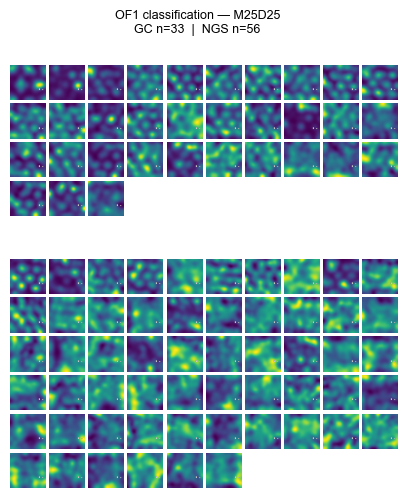

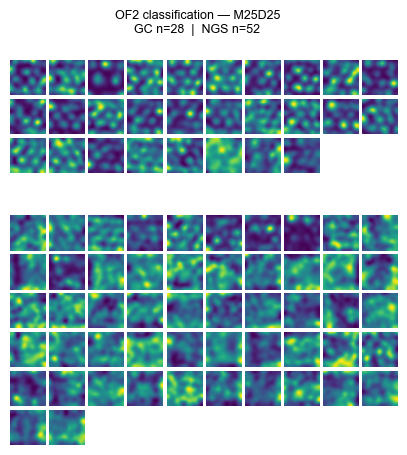

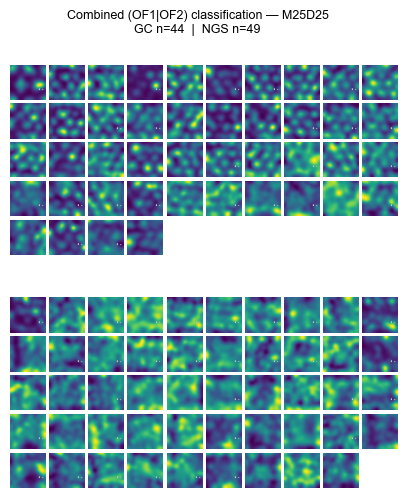

In [2]:
mouse_days = {25:[25]}

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing M{mouse} D{day:02}...")

        # Reset per-session accumulators
        s1 = _empty_scheme()
        s2 = _empty_scheme()
        sc = _empty_scheme()

        try:
            gcs_1, ngs_1, _, _, _, _ = cell_classification_of1(
                mouse, day, percentile_threshold=95, source_path=None, verbose=False, session='OF1',
            )
        except FileNotFoundError:
            gcs_1, ngs_1 = pd.DataFrame(), pd.DataFrame()
            print(f"  Missing OF1 files.")

        try:
            gcs_2, ngs_2, _, _, _, _ = cell_classification_of1(
                mouse, day, percentile_threshold=95, source_path=None, verbose=False, session='OF2',
            )
        except FileNotFoundError:
            gcs_2, ngs_2 = pd.DataFrame(), pd.DataFrame()
            print(f"  Missing OF2 files.")

        if len(gcs_1) == 0 and len(gcs_2) == 0:
            print(f"  No grid cells in either OF session, skipping.")
            continue

        shift_1 = gcs_1.travel.iloc[0] if len(gcs_1) > 0 else (gcs_2.travel.iloc[0] if len(gcs_2) > 0 else 0)
        shift_2 = gcs_2.travel.iloc[0] if len(gcs_2) > 0 else shift_1

        try:
            tcs_of1, _, _, _, _ = compute_of_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=True,
                fill_nans_from_neighbors=True, source_path=None,
                optimal_shift=shift_1, session='OF1',
            )
        except Exception as e:
            print(f"  OF1 maps failed: {e}")
            tcs_of1 = {}

        try:
            tcs_of2, _, _, _, _ = compute_of_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=True,
                fill_nans_from_neighbors=True, source_path=None,
                optimal_shift=shift_2, session='OF2',
            )
        except Exception as e:
            print(f"  OF2 maps failed: {e}")
            tcs_of2 = {}

        # --- Scheme 1: OF1 ---
        if len(gcs_1) > 0:
            s1['gcs_rows'].append(gcs_1)
            _fill_maps(gcs_1, tcs_of1, s1['gc_maps'])
        if len(ngs_1) > 0:
            s1['ngs_rows'].append(ngs_1)
            _fill_maps(ngs_1, tcs_of1, s1['ngs_maps'])

        # --- Scheme 2: OF2 ---
        if len(gcs_2) > 0:
            s2['gcs_rows'].append(gcs_2)
            _fill_maps(gcs_2, tcs_of2, s2['gc_maps'])
        if len(ngs_2) > 0:
            s2['ngs_rows'].append(ngs_2)
            _fill_maps(ngs_2, tcs_of2, s2['ngs_maps'])

        # --- Scheme 3: combined (OF1 ∪ OF2) ---
        # GCS = any cell GCS in OF1 OR OF2; one map per cell (best grid score wins)
        # NGS = any cell NGS in OF1 OR OF2 but NOT GCS in either; one map per cell (best grid score wins)
        gc1_ids = set(gcs_1['cluster_id'].tolist()) if len(gcs_1) > 0 else set()
        gc2_ids = set(gcs_2['cluster_id'].tolist()) if len(gcs_2) > 0 else set()
        combined_gc_ids = gc1_ids | gc2_ids

        gc_parts = [df for df in [gcs_1, gcs_2] if len(df) > 0]
        if gc_parts:
            gcs_comb = pd.concat(gc_parts).drop_duplicates('cluster_id').reset_index(drop=True)
            sc['gcs_rows'].append(gcs_comb)
            _fill_maps_best_score(gcs_comb, tcs_of1, tcs_of2, gcs_1, gcs_2, sc['gc_maps'])

        ngs_parts = [df for df in [ngs_1, ngs_2] if len(df) > 0]
        if ngs_parts:
            ngs_comb_all = pd.concat(ngs_parts).drop_duplicates('cluster_id').reset_index(drop=True)
            ngs_comb = ngs_comb_all[~ngs_comb_all['cluster_id'].isin(combined_gc_ids)]
            if len(ngs_comb) > 0:
                sc['ngs_rows'].append(ngs_comb)
                _fill_maps_best_score(ngs_comb, tcs_of1, tcs_of2, ngs_1, ngs_2, sc['ngs_maps'])

        # Finalise DataFrames
        for s in [s1, s2, sc]:
            s['gcs_all'] = pd.concat(s['gcs_rows'], ignore_index=True) if s['gcs_rows'] else pd.DataFrame()
            s['ngs_all'] = pd.concat(s['ngs_rows'], ignore_index=True) if s['ngs_rows'] else pd.DataFrame()

        print(f"OF1  - GC: {len(s1['gc_maps'])}, NGS: {len(s1['ngs_maps'])}")
        print(f"OF2  - GC: {len(s2['gc_maps'])}, NGS: {len(s2['ngs_maps'])}")
        print(f"Comb - GC: {len(sc['gc_maps'])}, NGS: {len(sc['ngs_maps'])}")

        # --- Plot 1: OF1 classification, OF1 rate maps ---
        plot_gc_and_ngs_of_rate_maps(
            s1['gc_maps'], s1['ngs_maps'],
            title=f"OF1 classification — M{mouse}D{day:02}",
            save_path=base + f"of1_classification_of1_maps_M{mouse}D{day:02}.pdf",
        )

        # --- Plot 2: OF2 classification, OF2 rate maps ---
        plot_gc_and_ngs_of_rate_maps(
            s2['gc_maps'], s2['ngs_maps'],
            title=f"OF2 classification — M{mouse}D{day:02}",
            save_path=base + f"of2_classification_of2_maps_M{mouse}D{day:02}.pdf",
        )

        # --- Plot 3: combined (OF1 | OF2) classification — best grid score map per cell ---
        plot_gc_and_ngs_of_rate_maps(
            sc['gc_maps'], sc['ngs_maps'],
            title=f"Combined (OF1|OF2) classification — M{mouse}D{day:02}",
            save_path=base + f"combined_classification_best_score_maps_M{mouse}D{day:02}.pdf",
        )


In [3]:
mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

all_gs_rows = []   # accumulates cross-session grid score data for the comparison plot
for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing M{mouse} D{day:02}...")

        # Reset per-session accumulators
        s1 = _empty_scheme()
        s2 = _empty_scheme()
        sc = _empty_scheme()

        try:
            gcs_1, ngs_1, _, _, _, all_c1 = cell_classification_of1(
                mouse, day, percentile_threshold=95, source_path=None, verbose=False, session='OF1',
            )
        except FileNotFoundError:
            gcs_1, ngs_1, all_c1 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
            print(f"  Missing OF1 files.")

        try:
            gcs_2, ngs_2, _, _, _, all_c2 = cell_classification_of1(
                mouse, day, percentile_threshold=95, source_path=None, verbose=False, session='OF2',
            )
        except FileNotFoundError:
            gcs_2, ngs_2, all_c2 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
            print(f"  Missing OF2 files.")

        if len(gcs_1) == 0 and len(gcs_2) == 0:
            print(f"  No grid cells in either OF session, skipping.")
            continue

        shift_1 = gcs_1.travel.iloc[0] if len(gcs_1) > 0 else (gcs_2.travel.iloc[0] if len(gcs_2) > 0 else 0)
        shift_2 = gcs_2.travel.iloc[0] if len(gcs_2) > 0 else shift_1

        try:
            tcs_of1, _, _, _, _ = compute_of_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=True,
                fill_nans_from_neighbors=True, source_path=None,
                optimal_shift=shift_1, session='OF1',
            )
        except Exception as e:
            print(f"  OF1 maps failed: {e}")
            tcs_of1 = {}

        try:
            tcs_of2, _, _, _, _ = compute_of_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=True,
                fill_nans_from_neighbors=True, source_path=None,
                optimal_shift=shift_2, session='OF2',
            )
        except Exception as e:
            print(f"  OF2 maps failed: {e}")
            tcs_of2 = {}

        # --- Scheme 1: OF1 ---
        if len(gcs_1) > 0:
            s1['gcs_rows'].append(gcs_1)
            _fill_maps(gcs_1, tcs_of1, s1['gc_maps'])
        if len(ngs_1) > 0:
            s1['ngs_rows'].append(ngs_1)
            _fill_maps(ngs_1, tcs_of1, s1['ngs_maps'])

        # --- Scheme 2: OF2 ---
        if len(gcs_2) > 0:
            s2['gcs_rows'].append(gcs_2)
            _fill_maps(gcs_2, tcs_of2, s2['gc_maps'])
        if len(ngs_2) > 0:
            s2['ngs_rows'].append(ngs_2)
            _fill_maps(ngs_2, tcs_of2, s2['ngs_maps'])

        # --- Scheme 3: combined (OF1 ∪ OF2) ---
        gc1_ids = set(gcs_1['cluster_id'].tolist()) if len(gcs_1) > 0 else set()
        gc2_ids = set(gcs_2['cluster_id'].tolist()) if len(gcs_2) > 0 else set()
        combined_gc_ids = gc1_ids | gc2_ids

        gc_parts = [df for df in [gcs_1, gcs_2] if len(df) > 0]
        if gc_parts:
            gcs_comb = pd.concat(gc_parts).drop_duplicates('cluster_id').reset_index(drop=True)
            sc['gcs_rows'].append(gcs_comb)
            _fill_maps_best_score(gcs_comb, tcs_of1, tcs_of2, gcs_1, gcs_2, sc['gc_maps'])

        ngs_parts = [df for df in [ngs_1, ngs_2] if len(df) > 0]
        if ngs_parts:
            ngs_comb_all = pd.concat(ngs_parts).drop_duplicates('cluster_id').reset_index(drop=True)
            ngs_comb = ngs_comb_all[~ngs_comb_all['cluster_id'].isin(combined_gc_ids)]
            if len(ngs_comb) > 0:
                sc['ngs_rows'].append(ngs_comb)
                _fill_maps_best_score(ngs_comb, tcs_of1, tcs_of2, ngs_1, ngs_2, sc['ngs_maps'])

        # Finalise DataFrames
        for s in [s1, s2, sc]:
            s['gcs_all'] = pd.concat(s['gcs_rows'], ignore_index=True) if s['gcs_rows'] else pd.DataFrame()
            s['ngs_all'] = pd.concat(s['ngs_rows'], ignore_index=True) if s['ngs_rows'] else pd.DataFrame()

        print(f"OF1  - GC: {len(s1['gc_maps'])}, NGS: {len(s1['ngs_maps'])}")
        print(f"OF2  - GC: {len(s2['gc_maps'])}, NGS: {len(s2['ngs_maps'])}")
        print(f"Comb - GC: {len(sc['gc_maps'])}, NGS: {len(sc['ngs_maps'])}")

        # --- Accumulate OF1 vs OF2 grid scores ---
        _df1 = all_c1[['cluster_id', 'grid_score', 'SC_x']].rename(columns={'grid_score': 'gs_of1'}) if len(all_c1) > 0 and 'grid_score' in all_c1.columns else pd.DataFrame(columns=['cluster_id', 'gs_of1', 'SC_x'])
        _df2 = all_c2[['cluster_id', 'grid_score']].rename(columns={'grid_score': 'gs_of2'}) if len(all_c2) > 0 and 'grid_score' in all_c2.columns else pd.DataFrame(columns=['cluster_id', 'gs_of2'])
        _merged = _df1.merge(_df2, on='cluster_id', how='outer')
        _merged['mouse'] = mouse
        _merged['day'] = day
        _merged['gc_of1'] = _merged['cluster_id'].isin(gc1_ids)
        _merged['gc_of2'] = _merged['cluster_id'].isin(gc2_ids)
        all_gs_rows.append(_merged)

# ── Build aggregate grid score comparison dataframe ────────────────────────
gs_df = pd.concat(all_gs_rows, ignore_index=True) if all_gs_rows else pd.DataFrame()

def _classify_session(row):
    if row['gc_of1'] and row['gc_of2']:
        return 'Both'
    elif row['gc_of1']:
        return 'OF1 only'
    elif row['gc_of2']:
        return 'OF2 only'
    else:
        return 'Neither'

gs_df['classification'] = gs_df.apply(_classify_session, axis=1)
print(f"\nGrid score comparison dataframe: {len(gs_df)} cells")
print(gs_df['classification'].value_counts())

Processing M20 D14...
OF1  - GC: 1, NGS: 101
OF2  - GC: 3, NGS: 49
Comb - GC: 4, NGS: 110
Processing M20 D15...
OF1  - GC: 1, NGS: 47
OF2  - GC: 2, NGS: 30
Comb - GC: 3, NGS: 51
Processing M20 D16...
OF1  - GC: 6, NGS: 154
OF2  - GC: 5, NGS: 138
Comb - GC: 11, NGS: 166
Processing M20 D17...
OF1  - GC: 2, NGS: 64
OF2  - GC: 1, NGS: 38
Comb - GC: 3, NGS: 73
Processing M20 D18...
OF1  - GC: 1, NGS: 92
OF2  - GC: 3, NGS: 68
Comb - GC: 4, NGS: 105
Processing M20 D19...
OF1  - GC: 0, NGS: 85
OF2  - GC: 1, NGS: 82
Comb - GC: 1, NGS: 91
Processing M20 D20...
OF1  - GC: 7, NGS: 76
OF2  - GC: 2, NGS: 76
Comb - GC: 8, NGS: 88
Processing M20 D21...
OF1  - GC: 1, NGS: 58
OF2  - GC: 0, NGS: 49
Comb - GC: 1, NGS: 70
Processing M20 D22...
  No grid cells in either OF session, skipping.
Processing M20 D23...
OF1  - GC: 0, NGS: 52
OF2  - GC: 6, NGS: 59
Comb - GC: 6, NGS: 68
Processing M20 D24...
OF1  - GC: 2, NGS: 66
OF2  - GC: 2, NGS: 55
Comb - GC: 4, NGS: 68
Processing M20 D25...
OF1  - GC: 13, NGS: 1

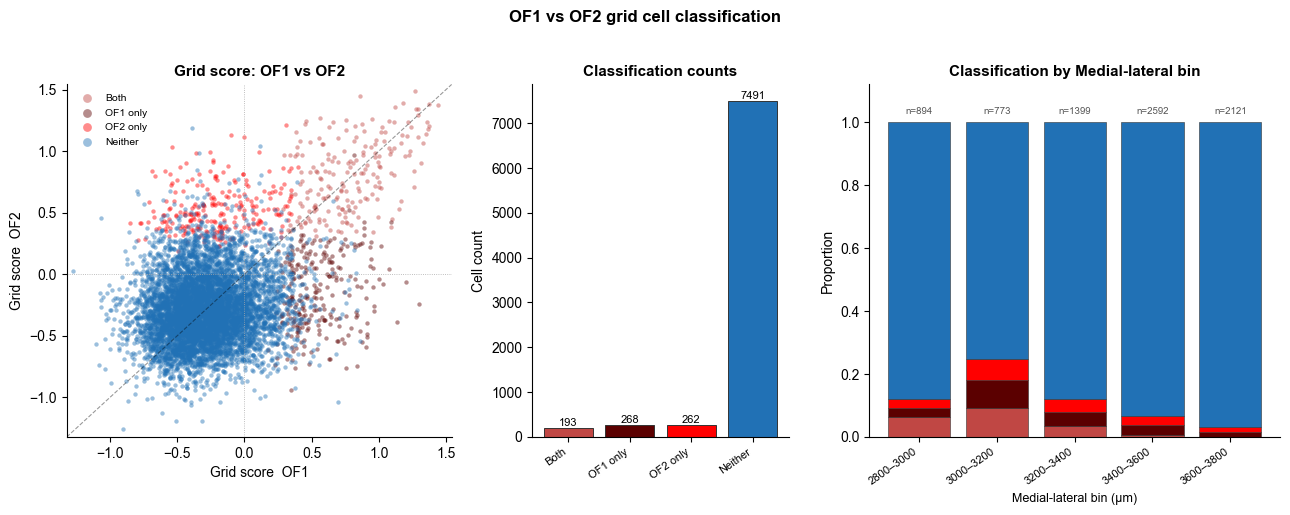

In [ ]:
import matplotlib.patches as mpatches

clf_palette = {
    'Both':     '#c04744',
    'OF1 only': '#5b0000',
    'OF2 only': '#ff0000',
    'Neither':  '#2171b5',
}
clf_order = ['Both', 'OF1 only', 'OF2 only', 'Neither']

bin_edges  = [2800, 3000, 3200, 3400, 3600, 3800]
bin_labels = ['2800–3000', '3000–3200', '3200–3400', '3400–3600', '3600–3800']
gs_df['SC_x_bin'] = pd.cut(
    gs_df['SC_x'].abs(), bins=bin_edges, labels=bin_labels, right=True,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [1.5, 1, 1.6]})
fig.subplots_adjust(wspace=0.38)

# Panel 1: scatter OF1 vs OF2
ax = axes[0]
_scatter_sub = gs_df.dropna(subset=['gs_of1', 'gs_of2'])
for clf in clf_order:
    _s = _scatter_sub[_scatter_sub['classification'] == clf]
    ax.scatter(_s['gs_of1'], _s['gs_of2'],
               c=clf_palette[clf], s=10, alpha=0.45, label=f'{clf}',
               rasterized=True, linewidths=0)
_lim = [
    min(_scatter_sub['gs_of1'].min(), _scatter_sub['gs_of2'].min()) - 0.05,
    max(_scatter_sub['gs_of1'].max(), _scatter_sub['gs_of2'].max()) + 0.05,
]
ax.plot(_lim, _lim, 'k--', lw=0.8, alpha=0.4)
ax.axhline(0, color='#aaa', lw=0.6, ls=':')
ax.axvline(0, color='#aaa', lw=0.6, ls=':')
ax.set_xlim(_lim); ax.set_ylim(_lim)
ax.set_xlabel('Grid score  OF1', fontsize=10)
ax.set_ylabel('Grid score  OF2', fontsize=10)
ax.set_title('Grid score: OF1 vs OF2', fontsize=11, fontweight='bold')
ax.legend(fontsize=7.5, frameon=False, markerscale=2, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: counts per classification
ax = axes[1]
counts = gs_df['classification'].value_counts().reindex(clf_order, fill_value=0)
bars = ax.bar(range(len(clf_order)), counts.values,
              color=[clf_palette[c] for c in clf_order],
              edgecolor='#333', linewidth=0.7)
ax.set_xticks(range(len(clf_order)))
ax.set_xticklabels(clf_order, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Cell count', fontsize=10)
ax.set_title('Classification counts', fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(v),
            ha='center', va='bottom', fontsize=8)

# Panel 3: stacked bar by M-L bin
ax = axes[2]
_bin_counts = (
    gs_df.dropna(subset=['SC_x_bin'])
    .groupby(['SC_x_bin', 'classification'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(bin_labels)
    .reindex(columns=clf_order, fill_value=0)
)
_bin_props = _bin_counts.div(_bin_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
bottom = np.zeros(len(_bin_props))
for clf in clf_order:
    vals = _bin_props[clf].values
    ax.bar(range(len(_bin_props)), vals, bottom=bottom,
           color=clf_palette[clf], edgecolor='#333', linewidth=0.4, label=clf)
    bottom += vals
ax.set_xticks(range(len(_bin_props)))
ax.set_xticklabels(_bin_props.index.tolist(), rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Proportion', fontsize=10)
ax.set_xlabel('Medial-lateral bin (µm)', fontsize=9)
ax.set_title('Classification by Medial-lateral bin', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for i, bin_lbl in enumerate(bin_labels):
    n = int(_bin_counts.loc[bin_lbl].sum()) if bin_lbl in _bin_counts.index else 0
    ax.text(i, 1.02, f'n={n}', ha='center', va='bottom', fontsize=7, color='#555')

fig.suptitle('OF1 vs OF2 grid cell classification', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(base + 'grid_score_of1_vs_of2_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()